     ┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ X ├
     └───┘
Statevector([0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.70710678+0.j],
            dims=(2, 2))


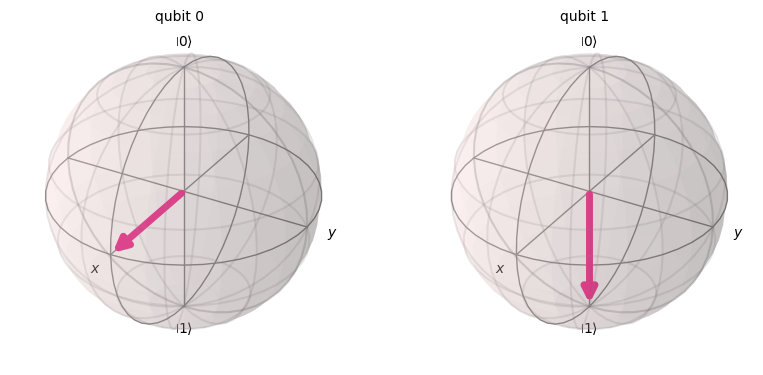

In [ ]:
#1State Vector 
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
 
qc = QuantumCircuit(2)
qc.h(0)
qc.x(1)
print(qc)
state = Statevector(qc)
print(state)
plot_bloch_multivector(state)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Probabilities: [0.4999999999999999, 0.4999999999999999]
{'0': 56, '1': 44}
      ┌───┐┌─┐
  q2: ┤ H ├┤M├
      └───┘└╥┘
c1: 1/══════╩═
            0 


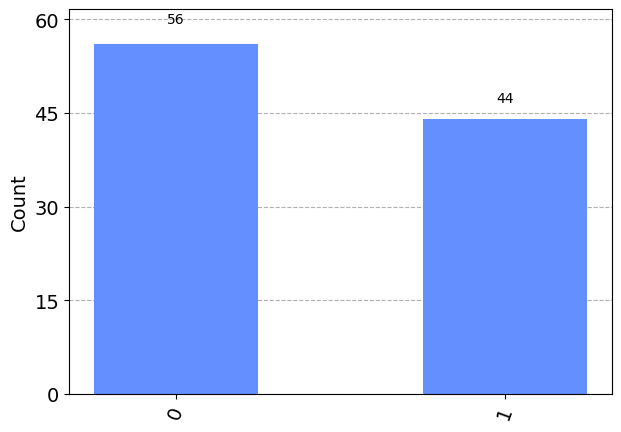

In [ ]:
#Single Qubit
from qiskit import QuantumCircuit,  ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# Create a quantum register with 1 qubit
qr = QuantumRegister(1)

# Create a classical register with 1 bit
cr = ClassicalRegister(1)

# Create a quantum circuit
circuit = QuantumCircuit(qr,cr)

# Apply a Hadamard gate to generate a superposition of |0⟩ and |1⟩
circuit.h(qr[0])

state = Statevector(circuit)
print(state)
# Convert state vector to probabilities
probabilities = [abs(amplitude)**2 for amplitude in state]

# Print or visualize the probabilities
print("Probabilities:", probabilities)

# Measure the qubit and store the result in the classical register
circuit.measure(qr, cr)
# Choose the AerSimulator backend
simulator = AerSimulator()

# Simulate the circuit
job = simulator.run(circuit, shots=100)

# Get the result
result = job.result()

# Print the counts
print(result.get_counts(circuit))

# Visualize the circuit
print(circuit)

# Visualize the measurement outcomes
plot_histogram(result.get_counts(circuit))



{'1111': 13, '0110': 5, '0100': 10, '1110': 3, '0000': 6, '0010': 8, '1100': 5, '1001': 9, '0101': 7, '1010': 6, '0111': 3, '0011': 5, '1000': 3, '1101': 7, '1011': 8, '0001': 2}
      ┌───┐┌─┐         
q2_0: ┤ H ├┤M├─────────
      ├───┤└╥┘┌─┐      
q2_1: ┤ H ├─╫─┤M├──────
      ├───┤ ║ └╥┘┌─┐   
q2_2: ┤ H ├─╫──╫─┤M├───
      ├───┤ ║  ║ └╥┘┌─┐
q2_3: ┤ H ├─╫──╫──╫─┤M├
      └───┘ ║  ║  ║ └╥┘
c1: 4/══════╩══╩══╩══╩═
            0  1  2  3 


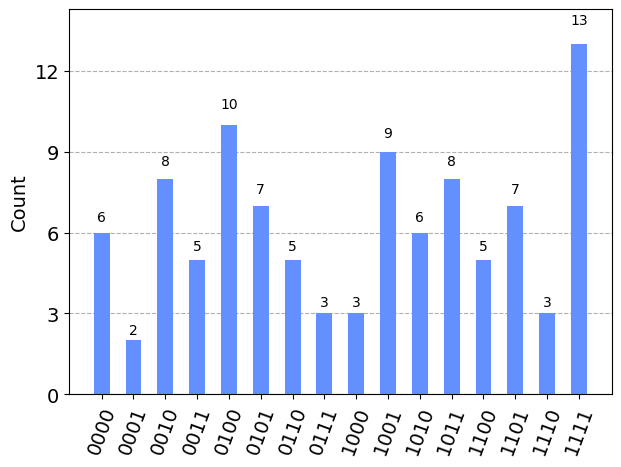

In [14]:
#Multiple Qubits
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import DensityMatrix

# Create a quantum register with 8 qubits
qr = QuantumRegister(4)

# Create a classical register with 8 bits
cr = ClassicalRegister(4)

# Create a quantum circuit
circuit = QuantumCircuit(qr, cr)

# Apply Hadamard gates to all qubits to generate a superposition of |0⟩ and |1⟩
for i in range(4):
    circuit.h(qr[i])

# Measure all qubits and store the results in the classical register
circuit.measure(qr, cr)

# Choose the AerSimulator backend
simulator = AerSimulator()

# Simulate the circuit
job = simulator.run(circuit, shots=100)

# Get the result
result = job.result()

# Print the counts
print(result.get_counts(circuit))

# Visualize the circuit
print(circuit)

# Visualize the measurement outcomes
plot_histogram(result.get_counts(circuit))


{'00': 60, '11': 40}
        ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 


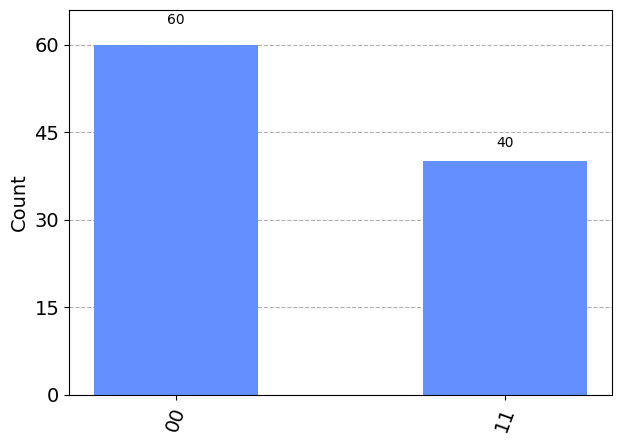

In [17]:
import numpy as np

# Import Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
simulator = AerSimulator()

# Create circuit
circ = QuantumCircuit(2)
circ.h(0)
circ.cx(0, 1)
circ.measure_all()

simulator = AerSimulator()
# Simulate the circuit
job = simulator.run(circ, shots=100)

# Get the result
result = job.result()

# Print the counts
print(result.get_counts(circ))

# Visualize the circuit
print(circ)

# Visualize the measurement outcomes
plot_histogram(result.get_counts(circ))


Statevector:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Density Matrix:
DensityMatrix([[0.5+0.j, 0. +0.j, 0. +0.j, 0.5+0.j],
               [0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j],
               [0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j],
               [0.5+0.j, 0. +0.j, 0. +0.j, 0.5+0.j]],
              dims=(2, 2))


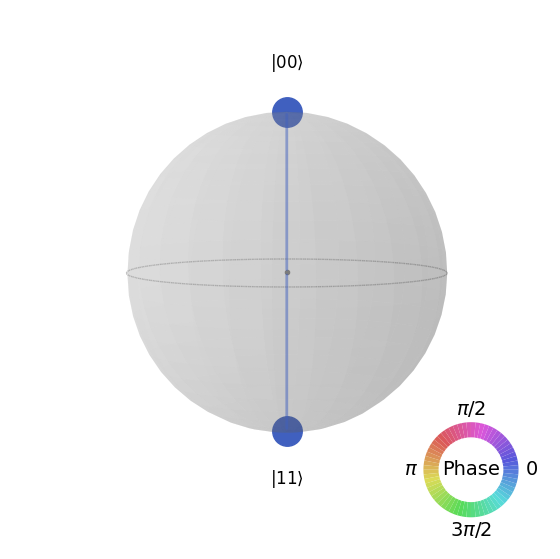

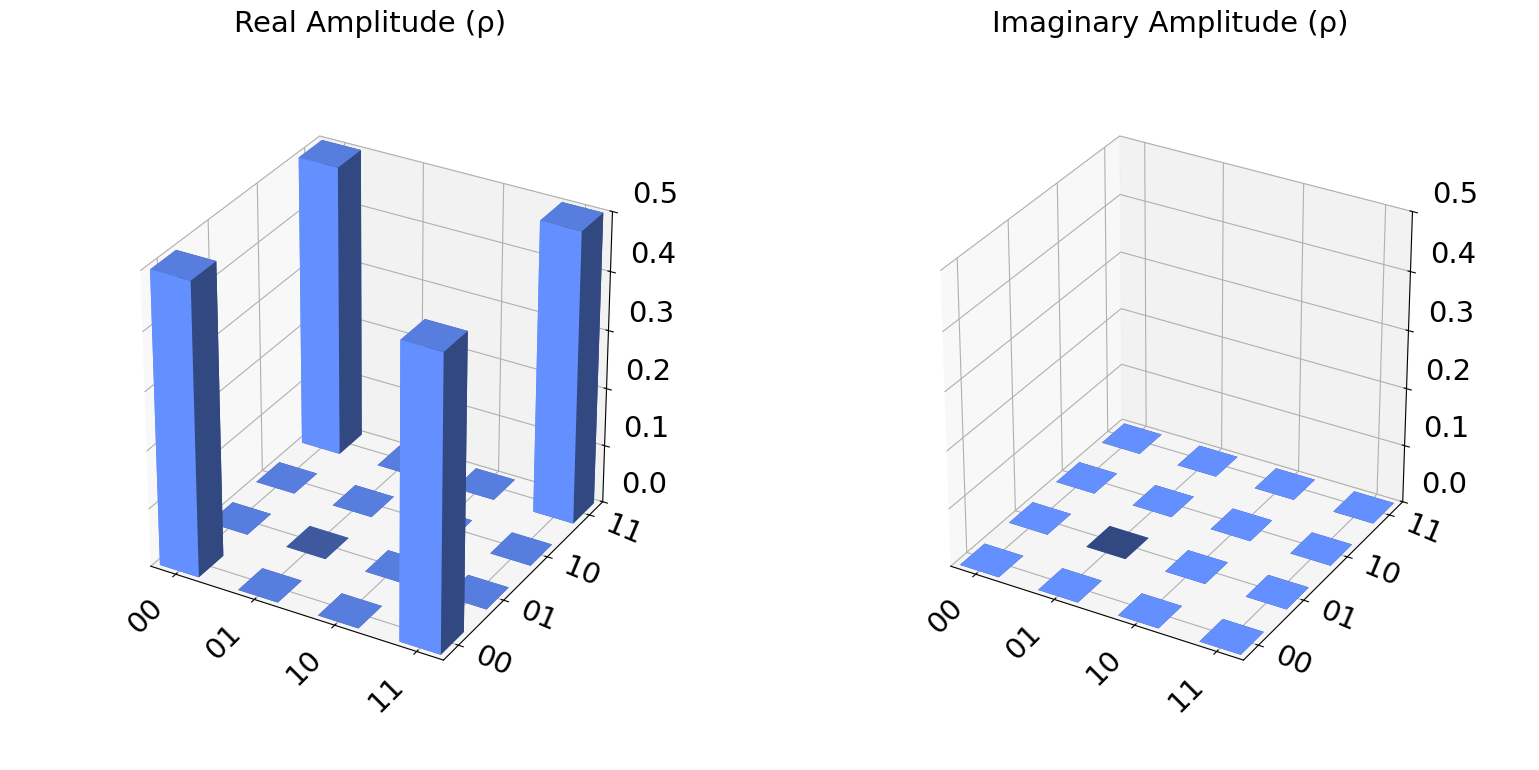

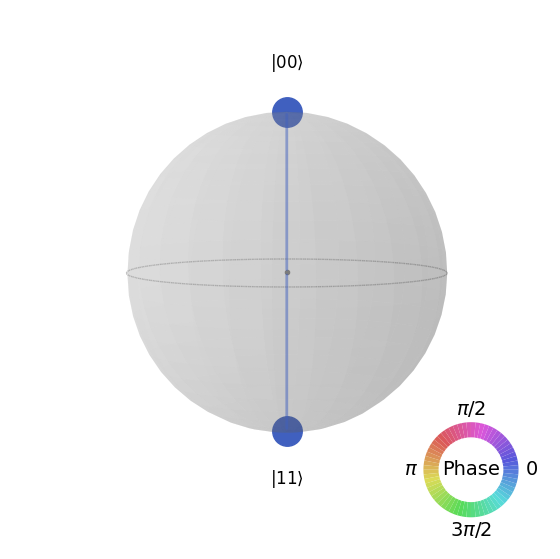

In [14]:
from math import pi
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city
from qiskit.visualization import plot_state_qsphere
from qiskit.visualization import plot_bloch_multivector
 
# Create a Bell state for demonstration
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
psi = Statevector(qc)
print("Statevector:")
print(psi)
print("Density Matrix:")
print(DensityMatrix(psi))
psi.draw("city")
psi.draw("qsphere")

     ┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ X ├
     └───┘
Statevector([0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.70710678+0.j],
            dims=(2, 2))
Density Matrix:
DensityMatrix([[0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j],
               [0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j],
               [0. +0.j, 0. +0.j, 0.5+0.j, 0.5+0.j],
               [0. +0.j, 0. +0.j, 0.5+0.j, 0.5+0.j]],
              dims=(2, 2))


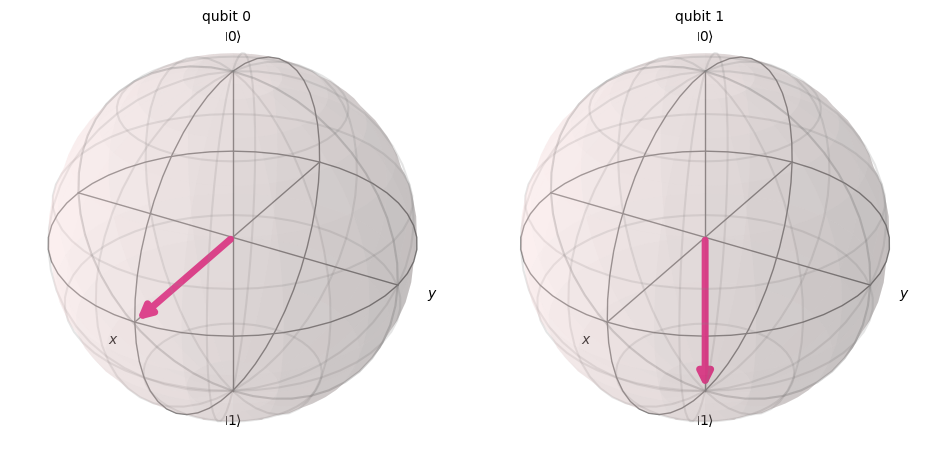

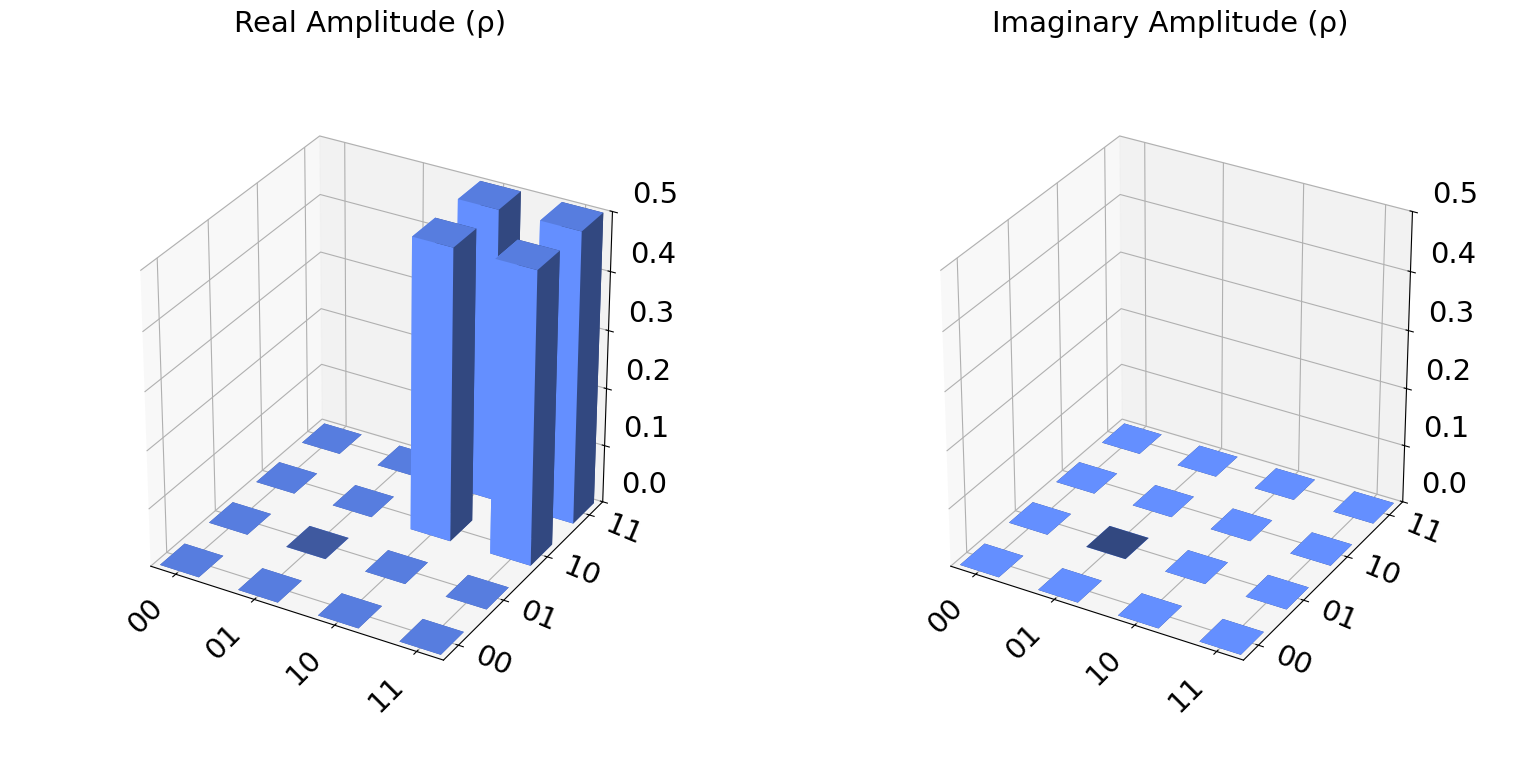

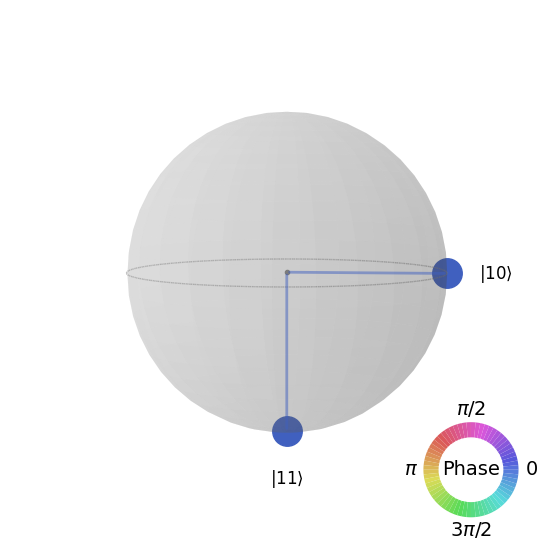

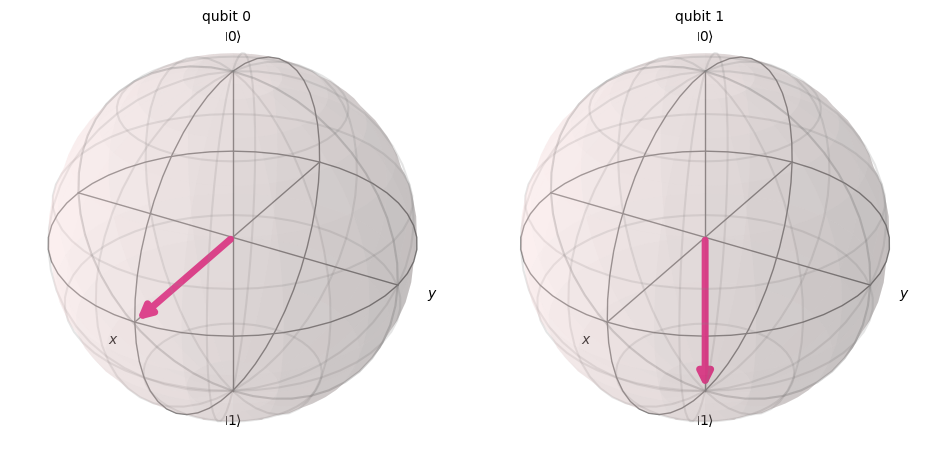

In [17]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city
from qiskit.visualization import plot_state_qsphere

 
qc = QuantumCircuit(2)
qc.h(0)
qc.x(1)
print(qc)
state = Statevector(qc)
print(state)
print("Density Matrix:")
print(DensityMatrix(state))
state.draw("city")
state.draw("qsphere")
plot_bloch_multivector(state)

Circuit for |+⟩:
   ┌───┐
q: ┤ H ├
   └───┘
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Density Matrix:
DensityMatrix([[0.5+0.j, 0.5+0.j],
               [0.5+0.j, 0.5+0.j]],
              dims=(2,))

Circuit for |−⟩:
   ┌───┐┌───┐
q: ┤ X ├┤ H ├
   └───┘└───┘
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))
Density Matrix:
DensityMatrix([[ 0.5+0.j, -0.5-0.j],
               [-0.5+0.j,  0.5+0.j]],
              dims=(2,))

Circuit for |+Y⟩:
   ┌───┐┌───┐
q: ┤ H ├┤ S ├
   └───┘└───┘
Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))
Density Matrix:
DensityMatrix([[0.5+0.j , 0. -0.5j],
               [0. +0.5j, 0.5+0.j ]],
              dims=(2,))

Circuit for |−Y⟩:
   ┌───┐┌───┐┌───┐
q: ┤ X ├┤ H ├┤ S ├
   └───┘└───┘└───┘
Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))
Density Matrix:
DensityMatrix([[0.5+0.j , 0. +0.5j],
               [0. -0.5j, 0.5+0.j ]],
              

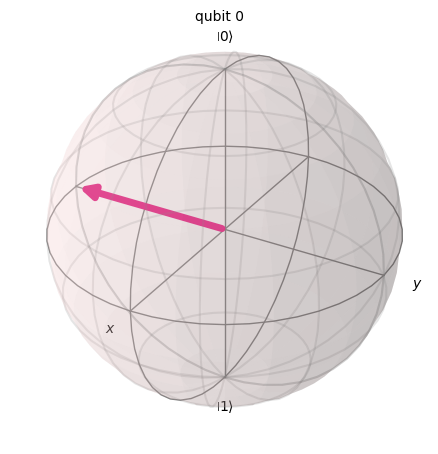

In [11]:
 ##|+⟩, |-⟩, |+Y⟩, and |-Y⟩,


from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city
from qiskit.visualization import plot_state_qsphere
import numpy as np

# Import Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
# Create a Quantum Circuit with one qubit
qc = QuantumCircuit(1)  # QuantumCircuit(num_qubits)

# |+⟩ state
qc.h(0)  # Apply Hadamard gate to qubit 0

# Draw the circuit
print("Circuit for |+⟩:")
print(qc)
state = Statevector(qc)
print(state)
print("Density Matrix:")
print(DensityMatrix(state))
state.draw("city")
state.draw("qsphere")
plot_bloch_multivector(state)

# Reset the circuit for the next state
qc = QuantumCircuit(1)

# |−⟩ state
qc.x(0)  # Apply X gate to make |1⟩ state
qc.h(0)  # Apply Hadamard gate to qubit 0

# Draw the circuit
print("\nCircuit for |−⟩:")
print(qc)
state = Statevector(qc)
print(state)
print("Density Matrix:")
print(DensityMatrix(state))
state.draw("city")
state.draw("qsphere")
plot_bloch_multivector(state)


qc = QuantumCircuit(1)
# |+Y⟩ state
qc.h(0)  # Apply Hadamard gate to qubit 0
qc.s(0)  # Apply Phase gate to qubit 0

# Draw the circuit
print("\nCircuit for |+Y⟩:")
print(qc)
state = Statevector(qc)
print(state)
print("Density Matrix:")
print(DensityMatrix(state))
state.draw("city")
state.draw("qsphere")
plot_bloch_multivector(state)



# Reset the circuit for the next state
qc = QuantumCircuit(1)

# |−Y⟩ state
qc.x(0)  # Apply X gate to make |1⟩ state
qc.h(0)  # Apply Hadamard gate to qubit 0
qc.s(0)  # Apply Phase gate to qubit 0

# Draw the circuit
print("\nCircuit for |−Y⟩:")
print(qc)
state = Statevector(qc)
print(state)
print("Density Matrix:")
print(DensityMatrix(state))
state.draw("city")
state.draw("qsphere")
plot_bloch_multivector(state)

Statevector([-0.70710678+0.j,  0.70710678+0.j],
            dims=(2,))
Density Matrix:
DensityMatrix([[ 0.5+0.j, -0.5+0.j],
               [-0.5-0.j,  0.5+0.j]],
              dims=(2,))


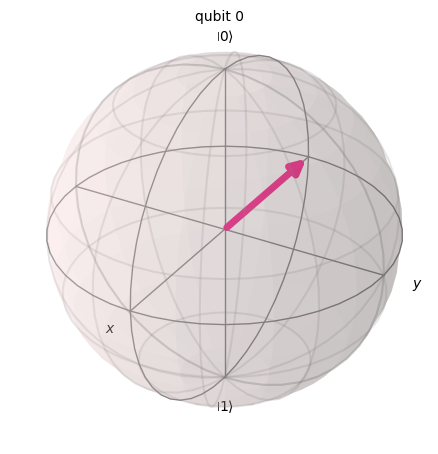

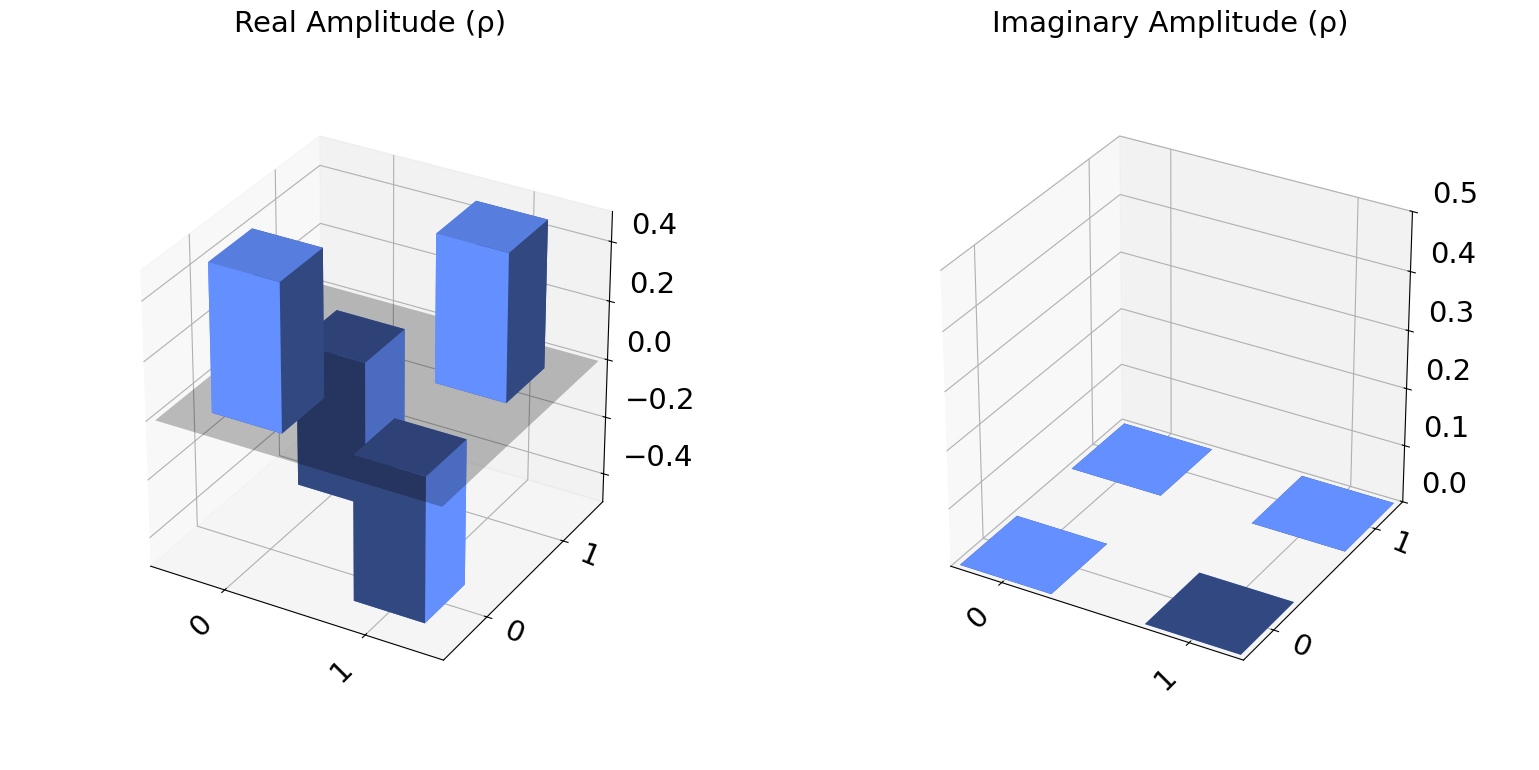

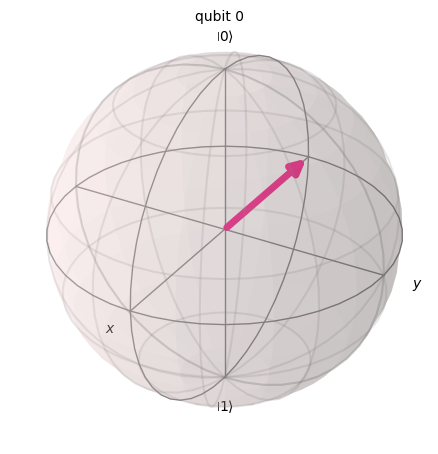

In [15]:
import numpy as np
%matplotlib inline
rotation_angle_x = np.deg2rad(270)  # Rotation angle around X-axis in radians
rotation_angle_y = np.deg2rad(90)  # Rotation angle around Y-axis in radians
rotation_angle_z = np.deg2rad(90) 
qc = QuantumCircuit(1)  # QuantumCircuit(num_qubits)

qc = QuantumCircuit(1)
qc.ry(rotation_angle_x, 0)
state = Statevector(qc)
print(state)
print("Density Matrix:")
print(DensityMatrix(state))
state.draw("city")
plot_bloch_multivector(state)

In [11]:
import qiskit.qasm2
from qiskit.circuit import QuantumCircuit
 
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
print(qiskit.qasm2.dumps(qc))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];


In [18]:
qiskit.qasm2.dump(qc, "myfile.qasm")

NameError: name 'qiskit' is not defined

In [13]:
import qiskit.qasm2
circuit = qiskit.qasm2.load("myfile.qasm")
print(circuit)

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


In [14]:
# the usual imports
import qiskit
import qiskit.qasm2
import numpy as np
import requests
import os
import json
#from google.colab import files

# current Quokka address:
req_str_qasm = 'http://quokka1.quokkacomputing.com/qsim/qasm'

In [15]:
code = qiskit.qasm2.dumps(circuit)

# by default, qiskit includes a library of gates not installed on the Quokka
# this code removes that
code = code[:14] + code[(14 + 22):]

print(code)

OPENQASM 2.0;
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];


In [20]:
data = {
    'script': code,
    'count': 10
}

result = requests.post(req_str_qasm, json=data)
json_obj = json.loads(result.content)

print(json_obj)


{'error': 'no error', 'error_code': 0, 'result': {'c': [[0, 0], [0, 0], [0, 0], [1, 1], [0, 0], [1, 1], [0, 0], [0, 0], [1, 1], [1, 1]]}}


In [17]:
bits = list(np.concatenate(list(json_obj['result'].values())).flat)

print(bits)

[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]


In [21]:
!pip install randtest
import randtest

randtest.random_score(bits)

  Using cached randtest-0.7-py3-none-any.whl


True